
AGE GROUP SUMMARY
           number_of_customers  average_income  average_CLV      total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683

TOP 10% CUSTOMERS
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     3

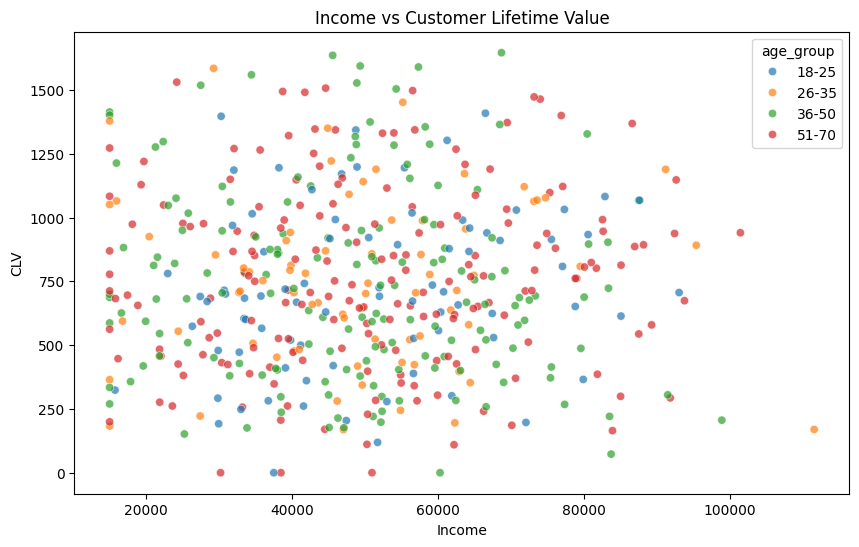

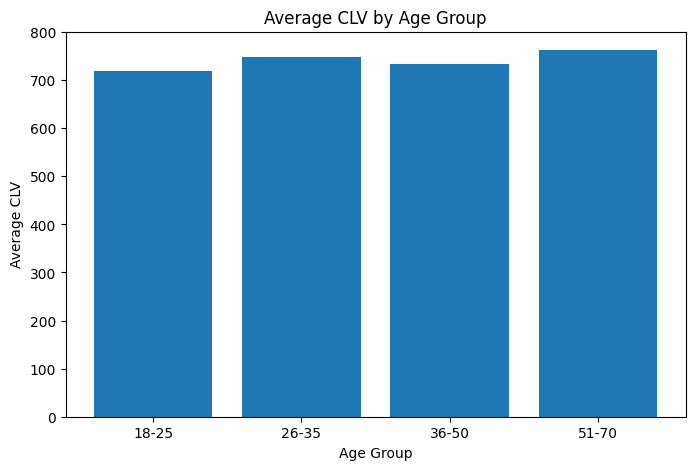

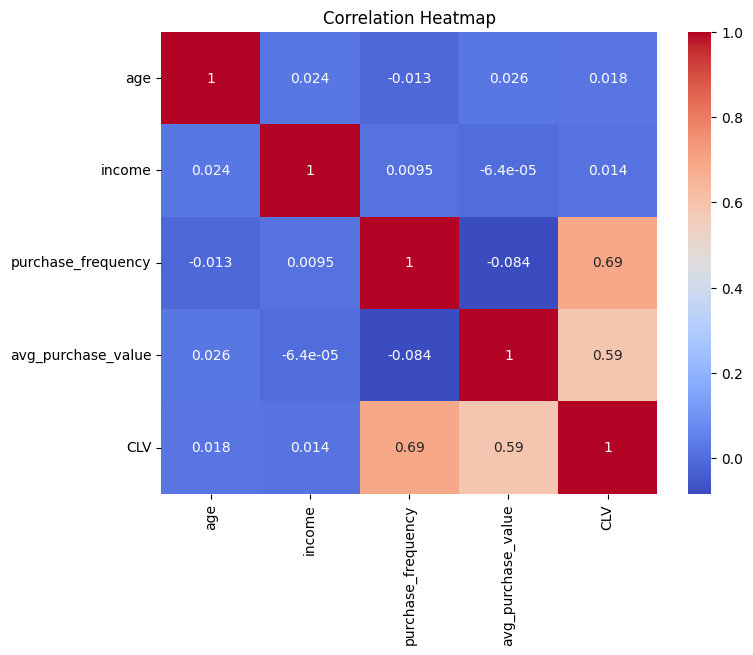

In [6]:
"""
Exercise 7: Integration Challenge
Customer Analytics for E-Commerce Company
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# --------------------------------------------------
# Task 1: Calculate CLV
# --------------------------------------------------

max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# --------------------------------------------------
# Task 2: Create Age Groups
# --------------------------------------------------

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

# --------------------------------------------------
# Task 3: Summary Statistics
# --------------------------------------------------

summary = customers.groupby('age_group').agg(
    number_of_customers=('age', 'count'),
    average_income=('income', 'mean'),
    average_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print("\nAGE GROUP SUMMARY")
print(summary)

# --------------------------------------------------
# Task 4: Top 10% Customers
# --------------------------------------------------

top_10_percent = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= top_10_percent
]

print("\nTOP 10% CUSTOMERS")
print(top_customers.head())

# --------------------------------------------------
# Visualization 1
# Income vs CLV
# --------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group',
    alpha=0.7
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.show()

# --------------------------------------------------
# Visualization 2
# Average CLV by Age Group
# --------------------------------------------------

plt.figure(figsize=(8, 5))

avg_clv = customers.groupby('age_group')['CLV'].mean()

plt.bar(avg_clv.index, avg_clv.values)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')

plt.show()

# --------------------------------------------------
# Visualization 3
# Correlation Heatmap
# --------------------------------------------------

plt.figure(figsize=(8, 6))

correlation = customers[
    [
        'age',
        'income',
        'purchase_frequency',
        'avg_purchase_value',
        'CLV'
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

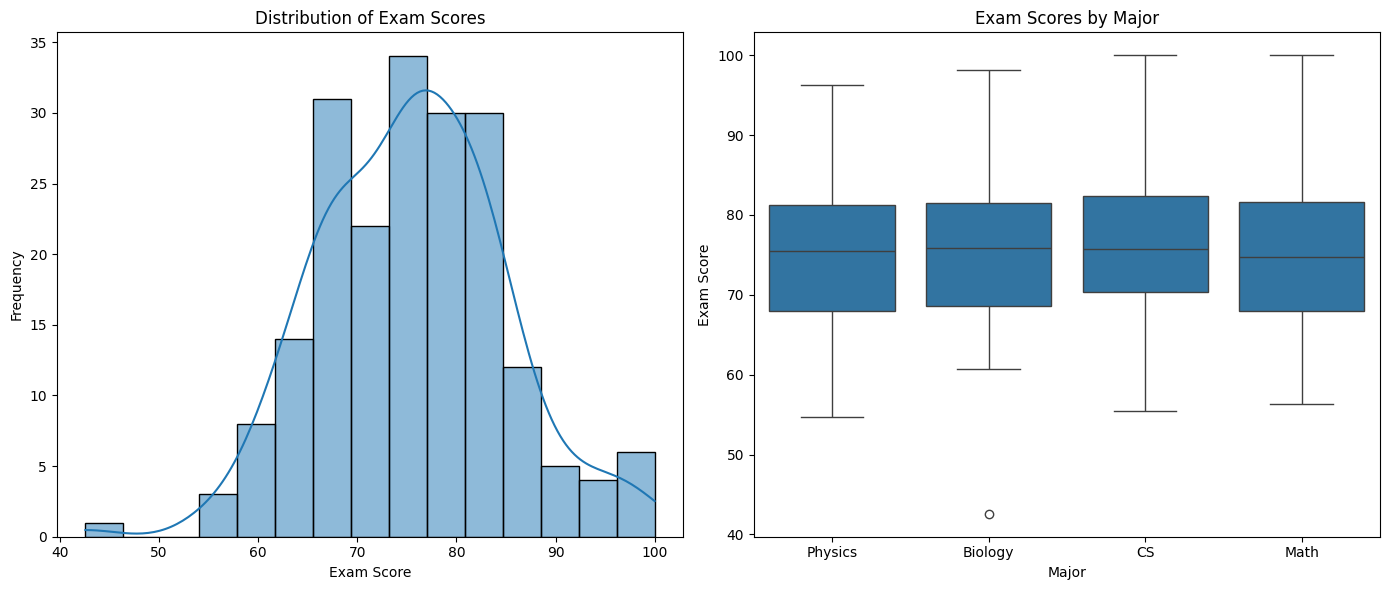

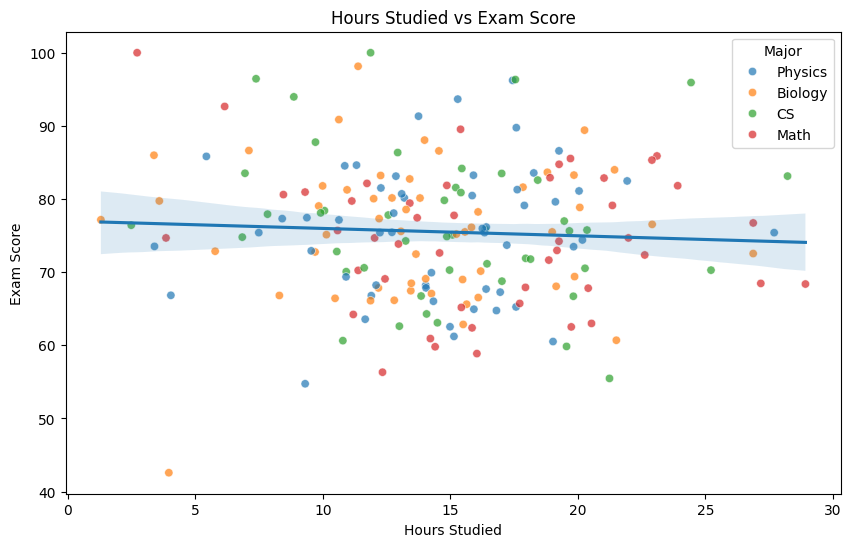

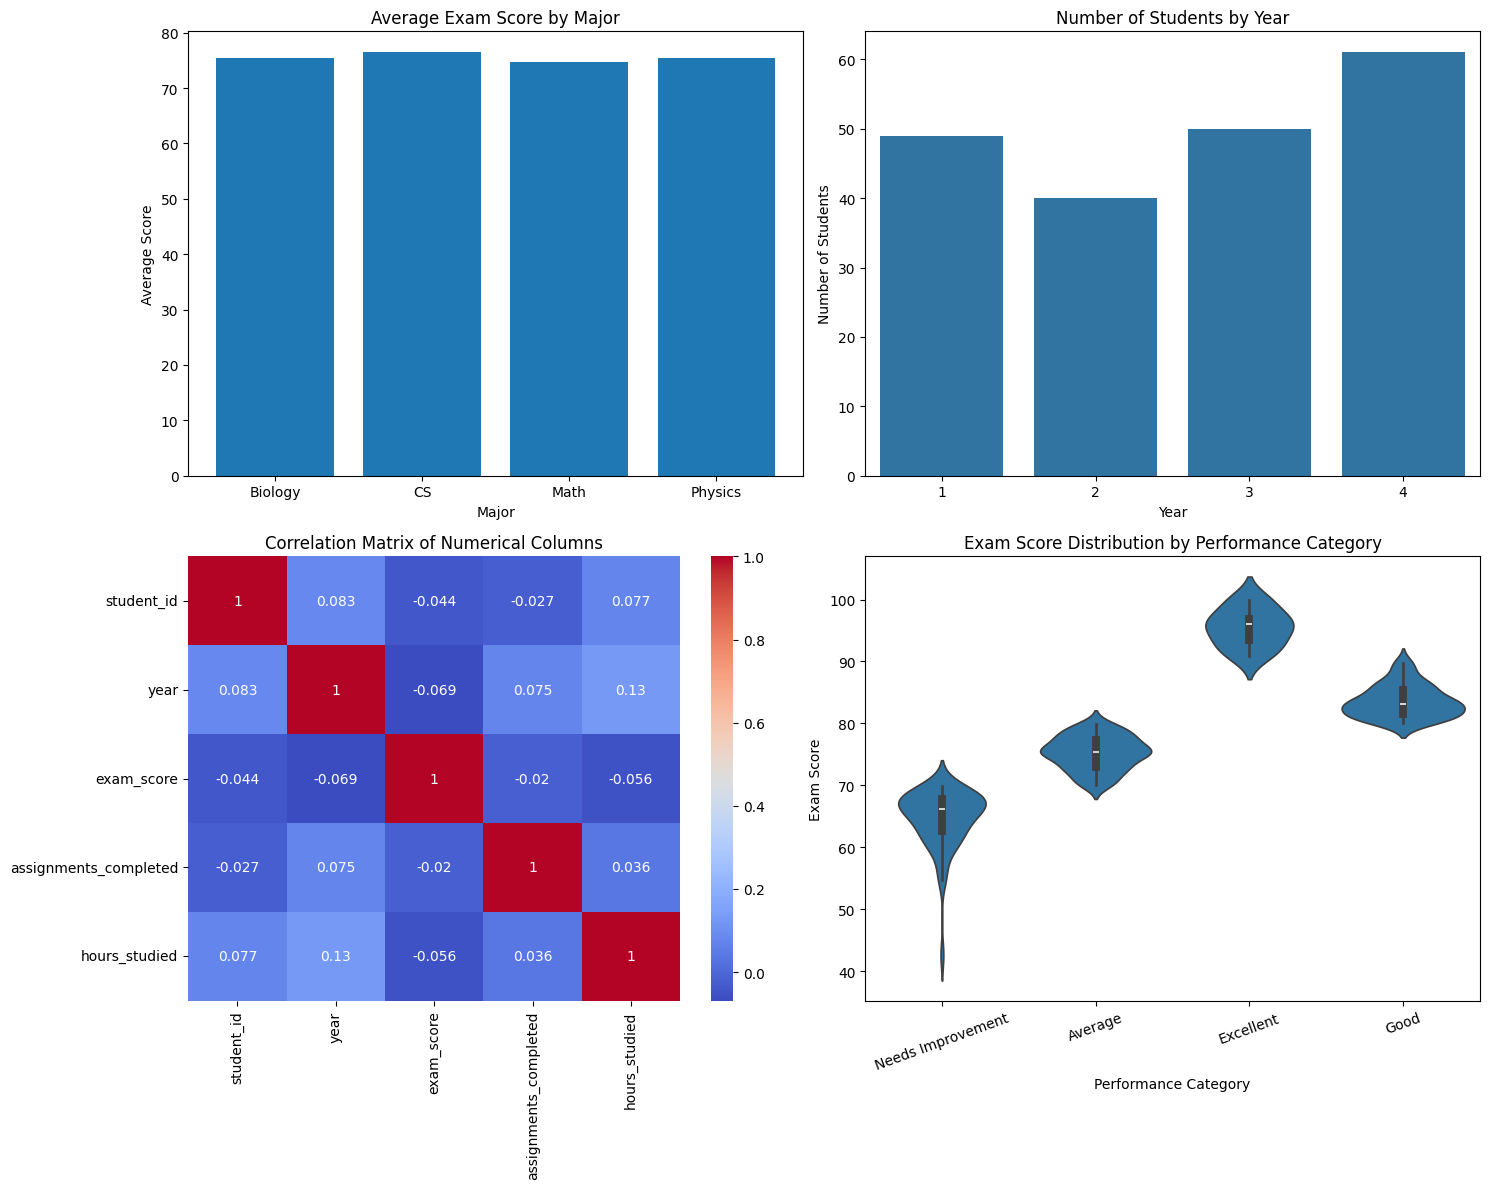

In [4]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate dataset from Exercise 5
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Clean missing values
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Create performance column
conditions = [
    df['exam_score'] > 90,
    df['exam_score'].between(80, 90, inclusive='both'),
    df['exam_score'].between(70, 80, inclusive='left'),
    df['exam_score'] < 70
]

categories = [
    'Excellent',
    'Good',
    'Average',
    'Needs Improvement'
]

df['performance'] = np.select(
    conditions,
    categories,
    default='Needs Improvement'
)


# Task 1: Distribution Visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'], bins=15, kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='major', y='exam_score')
plt.title('Exam Scores by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# Task 2: Relationship Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    alpha=0.7
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()


# Task 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# 2. Count plot: Number of students by year
sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Students')

# 3. Heatmap: Correlation matrix
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix of Numerical Columns')

# 4. Violin plot: Exam score by performance category
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Exam Score Distribution by Performance Category')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [3]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


# Task 1: Data Cleaning and Exploration
print("TASK 1: DATA CLEANING AND EXPLORATION")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Fill missing exam_score with mean score for student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median for student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# Task 2: Analysis
print("\nTASK 2: ANALYSIS")

average_score_by_major = df.groupby('major')['exam_score'].mean()

print("\nAverage exam score by major:")
print(average_score_by_major)

highest_major = average_score_by_major.idxmax()
highest_score = average_score_by_major.max()

print("\nMajor with the highest average exam score:")
print(f"{highest_major} with an average score of {highest_score:.2f}")

correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation between hours studied and exam score:")
print(correlation)

# Create performance column
conditions = [
    df['exam_score'] > 90,
    df['exam_score'].between(80, 90, inclusive='both'),
    df['exam_score'].between(70, 80, inclusive='left'),
    df['exam_score'] < 70
]

categories = [
    'Excellent',
    'Good',
    'Average',
    'Needs Improvement'
]

df['performance'] = np.select(
    conditions,
    categories,
    default='Needs Improvement'
)

print("\nPerformance counts:")
print(df['performance'].value_counts())


# Task 3: Advanced Analysis
print("\nTASK 3: ADVANCED ANALYSIS")

major_year_summary = df.groupby(['major', 'year']).agg(
    number_of_students=('student_id', 'count'),
    average_exam_score=('exam_score', 'mean'),
    average_hours_studied=('hours_studied', 'mean')
)

print("\nSummary by major and year:")
print(major_year_summary)

top_5_students = df.nlargest(5, 'exam_score', keep='all')

print("\nTop 5 students based on exam score:")
print(top_5_students[['student_id', 'major', 'year', 'exam_score']])

pivot_table = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot table: Average exam score by major and year:")
print(pivot_table)

TASK 1: DATA CLEANING AND EXPLORATION

First 5 rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    in

In [1]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
border_matrix = np.ones((5, 5))
border_matrix[1:-1, 1:-1] = 0

print("Task 1: Border Matrix")
print(border_matrix)


# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("\nTask 2: Normalized Data")
print("Column means:", normalized_data.mean(axis=0))
print("Column standard deviations:", normalized_data.std(axis=0))


# Task 3: Implement linear regression solution using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTask 3: Linear Regression Normal Equation")
print("Estimated coefficients:", theta_hat)
print("True coefficients:", true_theta)
print("Difference:", theta_hat - true_theta)

Task 1: Border Matrix
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2: Normalized Data
Column means: [-9.15933995e-17  1.11022302e-17 -8.88178420e-18]
Column standard deviations: [1. 1. 1.]

Task 3: Linear Regression Normal Equation
Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True coefficients: [ 2.5 -1.2  3.7]
Difference: [0.01723721 0.00216204 0.02399266]
